In [232]:
#Imports numpy for math and matplotlib for plotting.
import numpy as np
import matplotlib.pyplot as plt

#Main variables in the simulation.
#B0 is the constant magnetic field, sigma is the target standard deviation of the noise, and tau is the timescale of the noise.
#Deltat is the timestep, tmax is the total time of the evolution, and numTrials is the number of random noise trials.
B0 = 5.0
sigma = 0.30
tau = 0.50
deltat = 0.002
tmax = 5.0
numTrials = 10000
seed = 7
generationFactor = 32
batchSize = 20
omegaMin = 0.01/tau
omegaMax = 1.0/tau


#Defines all of the five noise colors, their labels for the plots, the colors of their plots, and their power spectral density power-law exponents.
noiseTypes = ["red", "pink", "white", "blue", "violet"]
noiseLabels = {"red": "Red", "pink": "Pink", "white": "White", "blue": "Blue", "violet": "Violet"}
noiseColors = {"red": "red", "pink": "hotpink", "white": "black", "blue": "blue", "violet": "purple"}
noiseExponents = {"red": -2.0, "pink": -1.0, "white": 0.0, "blue": 1.0, "violet": 2.0}

#Creates the time grid as well as a larger Fast Fourier Transform grid, which generates the colored noise.
numPoints = int(round(tmax/deltat))+1
timeList = np.arange(numPoints)*deltat
numGenerated = 2**int(np.ceil(np.log2(generationFactor*numPoints)))
startIndex = (numGenerated-numPoints)//2
frequencyList = np.fft.rfftfreq(numGenerated, d=deltat)
omegaList = 2.0*np.pi*frequencyList

#Places the Hahn echo pi pulse about the y-axis halfway through the total evolution time.
pulseTime = tmax/2.0
pulseIndex = int(round(pulseTime/deltat))

#Makes fontsize consistent for all plots.
plt.rcParams.update({"font.size": 13, "axes.titlesize": 20, "axes.labelsize": 16, "legend.fontsize": 11})

In [233]:
#Creates the power spectral density weighting for the noise-color exponent in the chosen frequency band.
#Inputs: Omega has angular frequencies, and exponent determines the color of the noise.
#Output: Frequency-dependent power spectral density weights.
def coloredPSDWeight(omega, exponent):
    omegaSafe = np.maximum(omega, omegaMin)
    weight = (omegaSafe*tau)**exponent
    frequencyMask = (omega>=omegaMin)&(omega<=omegaMax)
    weight = weight*frequencyMask
    weight[0] = 0.0
    return weight

#Creates multiple random trajectories of colored noise through filtering white noise in the frequency domain.
#Inputs: Exponent determines what color the noise is and colorSeed gives the random seed.
#Output: numTrials number of colored-noise trajectories with sigma as the standard deviation.
def generateColoredTrials(exponent, colorSeed):
    rng = np.random.default_rng(colorSeed)
    output = np.empty((numTrials, numPoints), dtype=np.float32)
    filterAmplitude = np.sqrt(coloredPSDWeight(omegaList, exponent))
    row = 0

    #Creates the trials in small batches to reduce usage of memory.
    while row<numTrials:
        currentBatch = min(batchSize, numTrials-row)
        whiteNoise = rng.normal(size=(currentBatch, numGenerated)).astype(np.float32)

        #Transforms the white noise to the frequency space, then applies the filter of the colored power spectral density, then transforms back to time.
        whiteSpectrum = np.fft.rfft(whiteNoise, axis=1)
        filteredNoise = np.fft.irfft(whiteSpectrum*filterAmplitude[None, :], n=numGenerated, axis=1)
        output[row:row+currentBatch] = filteredNoise[:, startIndex:startIndex+numPoints]
        row += currentBatch

    #Makes sure the noise is centered at zero and rescales every color to the same standard deviation.
    output -= np.mean(output)
    output *= sigma/np.std(output)
    return output

#Calculates the overall phase of the spin from the total magnetic field.
#Input: noiseArray has the time-dependent noise trajectories.
#Output: Accumulated phase for each trial at each time.
def calculateCumulativePhase(noiseArray):
    BzData = B0+noiseArray.astype(np.float64)

    #Utilizes trapezoidal integration in order to approximate the accumulated phase during every timestep.
    intervalPhase = 0.5*(BzData[:, :-1]+BzData[:, 1:])*deltat

    #Adds all the phase contributions over time, starting with zero phase at time t = 0.
    cumulativePhase = np.concatenate([np.zeros((numTrials, 1)), np.cumsum(intervalPhase, axis=1)], axis=1)
    return cumulativePhase

In [234]:
#Generates the random noise trajectories for each noise color using a different random seed.
noiseData = {}

for index, noiseType in enumerate(noiseTypes):
    noiseData[noiseType] = generateColoredTrials(noiseExponents[noiseType], seed+1000*index)

#Stores the spin signal without Hahn echo, with one fixed Hahn pulse, and at the final Hahn echo time.
signalNoEcho = {}
signalFixedEcho = {}
signalFinalEcho = {}

#Selects total evolution times with an exact midpoint on the numerical time grid.
echoIndices = np.arange(0, numPoints, 2)
totalTimeList = timeList[echoIndices]
halfIndices = echoIndices//2

#Calculates the accumulated phase and average X expectation value for every noise color.
for noiseType in noiseTypes:
    cumulativePhase = calculateCumulativePhase(noiseData[noiseType])

    #Calculates the spin signal without a Hahn echo pulse.
    signalNoEcho[noiseType] = np.mean(np.cos(2.0*cumulativePhase), axis=0)

    #Models an ideal fixed Hahn echo pulse by reversing phase accumulation after the midpoint pulse.
    fixedEchoPhase = cumulativePhase.copy()
    fixedEchoPhase[:, pulseIndex+1:] = 2.0*cumulativePhase[:, [pulseIndex]]-cumulativePhase[:, pulseIndex+1:]
    signalFixedEcho[noiseType] = np.mean(np.cos(2.0*fixedEchoPhase), axis=0)

    #Calculates the final Hahn echo signal with the pulse halfway through each total evolution time.
    finalEchoPhase = 2.0*cumulativePhase[:, halfIndices]-cumulativePhase[:, echoIndices]
    signalFinalEcho[noiseType] = np.mean(np.cos(2.0*finalEchoPhase), axis=0)

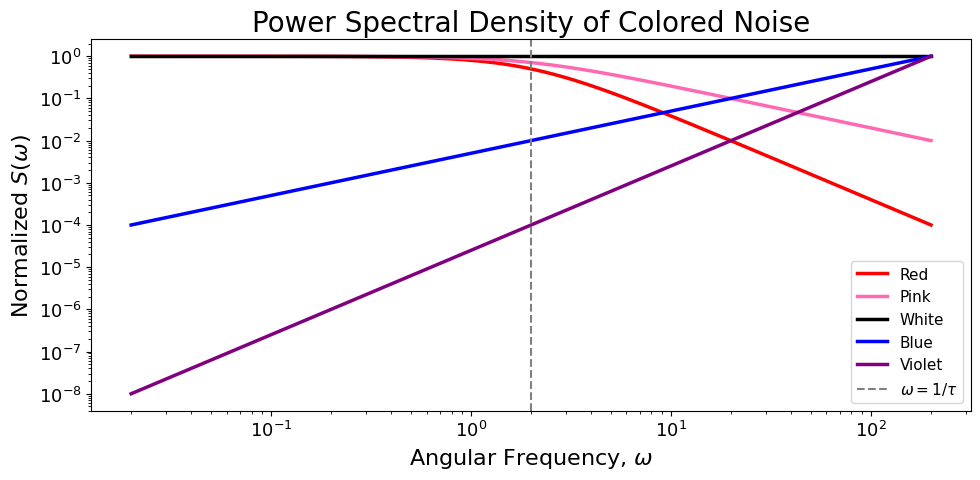

In [235]:
#Creates the frequency range that is used to plot the ideal power spectral densities.
omegaPlot = np.logspace(np.log10(0.01/tau), np.log10(100.0/tau), 1000)
turnoverFrequency = 1.0/tau

plt.figure(figsize=(10, 5))

#Calculates and plots the ideal shape of the power spectral density per noise color.
for noiseType in noiseTypes:
    exponent = noiseExponents[noiseType]

    #Adds a low-frequency cutoff for red and pink noise so the power spectral density does not diverge near zero frequency.
    if exponent<0:
        effectiveOmega = np.sqrt(omegaPlot**2+turnoverFrequency**2)
        idealPSD = (effectiveOmega*tau)**exponent
    else:
        idealPSD = (omegaPlot*tau)**exponent

    #Normalizes every power spectral density so they can be fairly compared.
    idealPSD = idealPSD/np.max(idealPSD)
    plt.loglog(omegaPlot, idealPSD, color=noiseColors[noiseType], label=noiseLabels[noiseType], linewidth=2.5)

#Marks the cutoff frequency based on tau.
plt.axvline(turnoverFrequency, color="gray", linestyle="--", linewidth=1.5, label=r"$\omega=1/\tau$")
plt.title("Power Spectral Density of Colored Noise")
plt.xlabel(r"Angular Frequency, $\omega$")
plt.ylabel(r"Normalized $S(\omega)$")
plt.legend()
plt.tight_layout()
plt.show()

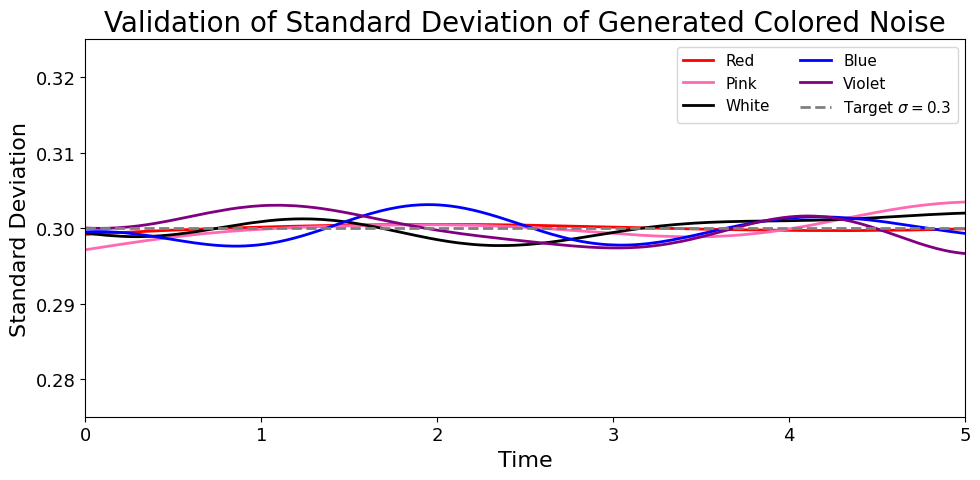

In [236]:
#Checks to make sure that every noise color converges to the same standard deviation over time.
plt.figure(figsize=(10, 5))

for noiseType in noiseTypes:
    standardDeviationList = np.std(noiseData[noiseType], axis=0)
    plt.plot(timeList, standardDeviationList, color=noiseColors[noiseType], label=noiseLabels[noiseType], linewidth=2.0)

#Shows the target standard deviation used to keep the overall strength of noise consistent.
plt.axhline(sigma, color="gray", linestyle="--", linewidth=2, label=rf"Target $\sigma={sigma}$")

plt.title("Validation of Standard Deviation of Generated Colored Noise")
plt.xlabel("Time")
plt.ylabel("Standard Deviation")

plt.xlim(0.0, tmax)
plt.ylim(sigma-0.025, sigma+0.025)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

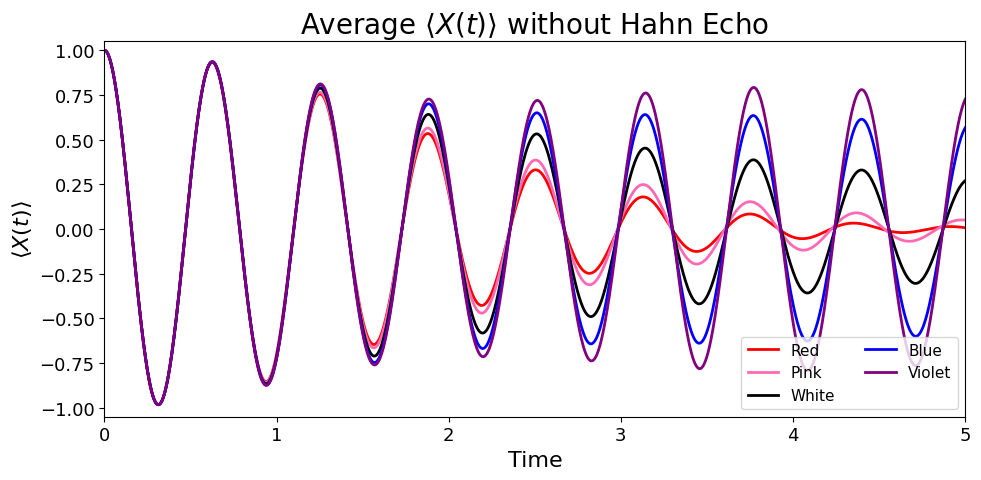

In [237]:
#Calculates the average expectation value of the x-component of the spin without Hahn echo for each noise color.
averageXNoHahn = {}

for noiseType in noiseTypes:
    cumulativePhase = calculateCumulativePhase(noiseData[noiseType])

    #Averages the expectation value of the x-component of the spin across all random noise trials at each time.
    averageXNoHahn[noiseType] = np.mean(np.cos(2.0*cumulativePhase), axis=0)

#Plots the average X evolution to show the dephasing without a Hahn echo pulse being applied.
plt.figure(figsize=(10, 5))

for noiseType in noiseTypes:
    plt.plot(timeList, averageXNoHahn[noiseType], color=noiseColors[noiseType], label=noiseLabels[noiseType], linewidth=2)

plt.title(r"Average $\langle X(t)\rangle$ without Hahn Echo")
plt.xlabel("Time")
plt.ylabel(r"$\langle X(t)\rangle$")

plt.xlim(0.0, tmax)
plt.ylim(-1.05, 1.05)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

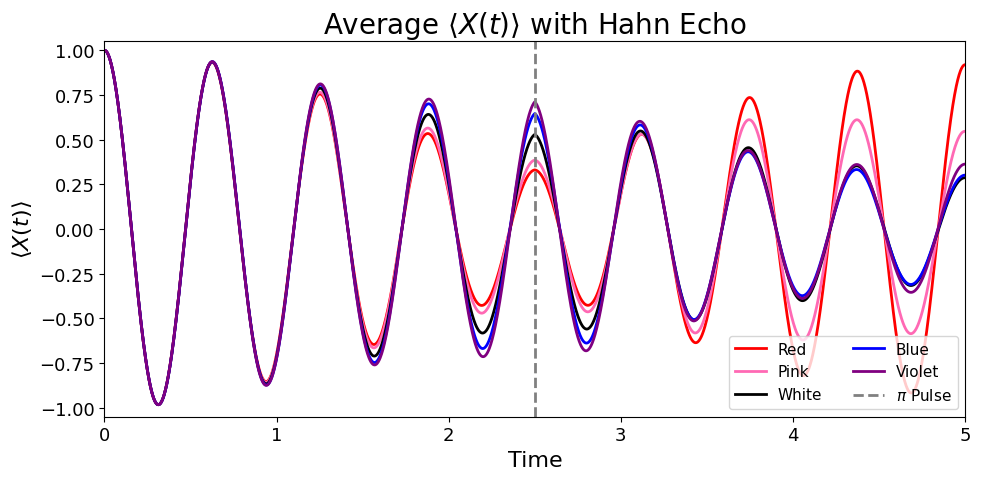

In [238]:
#Plots the average x-component of the spin when an ideal Hahn echo sequence is applied at the midpoint.
plt.figure(figsize=(10, 5))

for noiseType in noiseTypes:
    plt.plot(timeList, signalFixedEcho[noiseType], color=noiseColors[noiseType], label=noiseLabels[noiseType], linewidth=2)

#Marks the time when the pi-pulse about the y-axis is applied.
plt.axvline(pulseTime, color="gray", linestyle="--", linewidth=2, label=r"$\pi$ Pulse")

plt.title(r"Average $\langle X(t)\rangle$ with Hahn Echo")
plt.xlabel("Time")
plt.ylabel(r"$\langle X(t)\rangle$")

plt.xlim(0.0, tmax)
plt.ylim(-1.05, 1.05)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

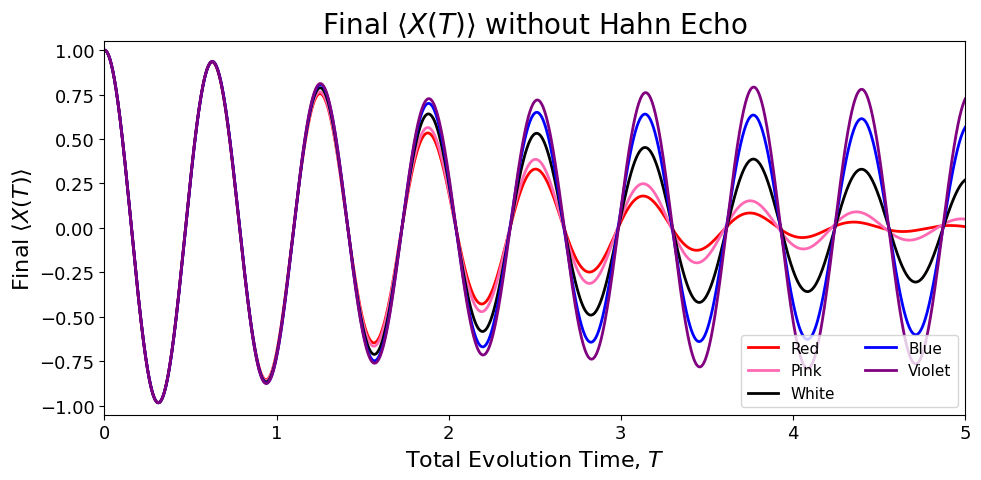

In [239]:
#Plots the final expectation value of the x-component of the spin to compare dephasing between noise colors.
plt.figure(figsize=(10, 5))

for noiseType in noiseTypes:
    plt.plot(timeList, signalNoEcho[noiseType], color=noiseColors[noiseType], label=noiseLabels[noiseType], linewidth=2)

plt.title(r"Final $\langle X(T)\rangle$ without Hahn Echo")
plt.xlabel(r"Total Evolution Time, $T$")
plt.ylabel(r"Final $\langle X(T)\rangle$")

plt.xlim(0.0, tmax)
plt.ylim(-1.05, 1.05)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

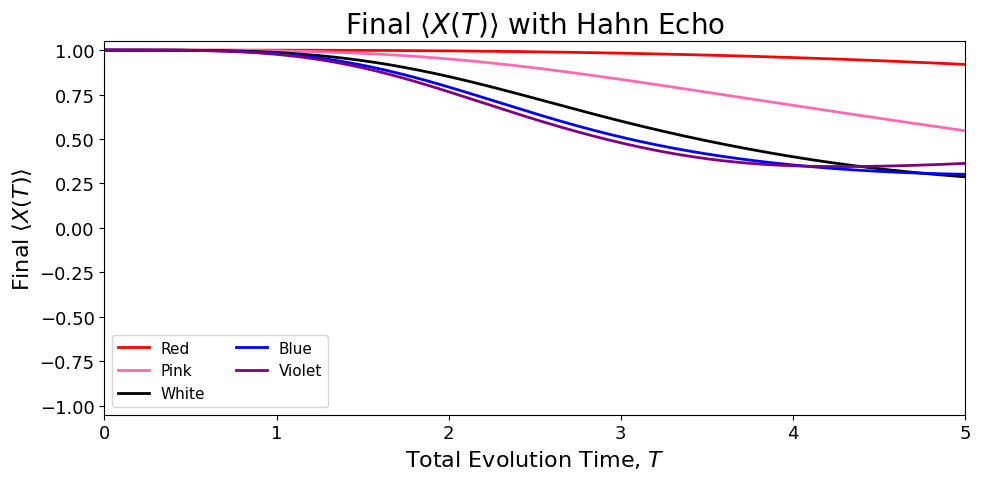

In [240]:
#Plots the final expectation value of the x-component of the spin where each time is total evolution time where a Hahn echo is applied halfway through each time.
plt.figure(figsize=(10, 5))

#Each point represents a trial with a pi-pulse about the y-axis halfway through that specific total evolution time.
for noiseType in noiseTypes:
    plt.plot(totalTimeList, signalFinalEcho[noiseType], color=noiseColors[noiseType], label=noiseLabels[noiseType], linewidth=2)

plt.title(r"Final $\langle X(T)\rangle$ with Hahn Echo")
plt.xlabel(r"Total Evolution Time, $T$")
plt.ylabel(r"Final $\langle X(T)\rangle$")

plt.xlim(0.0, tmax)
plt.ylim(-1.05, 1.05)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

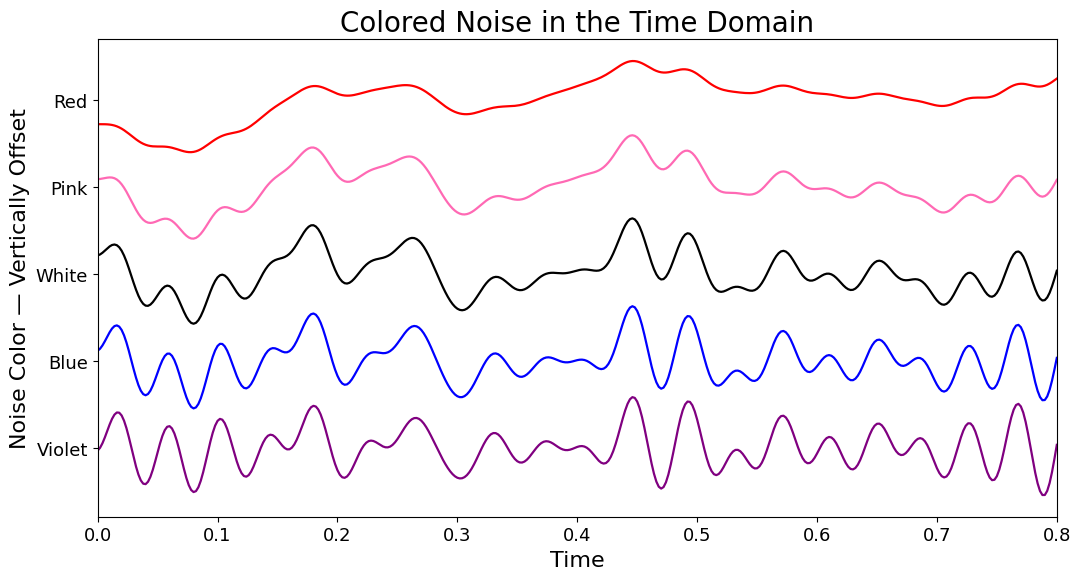

In [241]:
#Defines a shorter time and wider frequency range to clearly show differences between colors of noise.
displayTime = .8
displayPoints = int(round(displayTime/deltat))+1
displayTimeList = np.arange(displayPoints)*deltat
displayOmegaMin = 0.05/tau
displayOmegaMax = 80.0/tau
numDisplayModes = 300
displayOmegaList = np.logspace(np.log10(displayOmegaMin), np.log10(displayOmegaMax), numDisplayModes)
displayDeltaOmega = np.gradient(displayOmegaList)
rng = np.random.default_rng(seed+50000)

#Uses the same random phases for each color so the effect of different frequency distributions can be consistently compared.
sharedPhaseList = rng.uniform(0.0, 2.0*np.pi, numDisplayModes)
displayNoiseData = {}

#Creates each noise signal from frequency components weighted according to its power spectral density.
for noiseType in noiseTypes:
    exponent = noiseExponents[noiseType]
    displayPSD = (displayOmegaList*tau)**exponent
    modeAmplitude = np.sqrt(2.0*displayPSD*displayDeltaOmega)
    displayedNoise = np.sum(modeAmplitude[:, None]*np.cos(displayOmegaList[:, None]*displayTimeList[None, :]+sharedPhaseList[:, None]), axis=0)

    #Normalizes and centers each noise signal to the same standard deviation.
    displayedNoise -= np.mean(displayedNoise)
    displayedNoise *= sigma/np.std(displayedNoise)
    displayNoiseData[noiseType] = displayedNoise

#Offsets all noise traces to easily compare their time-domain behavior.
offsetSpacing = 1.25
offsets = {noiseType: offsetSpacing*(len(noiseTypes)-1-index) for index, noiseType in enumerate(noiseTypes)}

plt.figure(figsize=(11, 6))

for noiseType in noiseTypes:
    plt.plot(displayTimeList, displayNoiseData[noiseType]+offsets[noiseType], color=noiseColors[noiseType], linewidth=1.6)

plt.title("Colored Noise in the Time Domain")
plt.xlabel("Time")
plt.ylabel("Noise Color — Vertically Offset")

plt.yticks([offsets[noiseType] for noiseType in noiseTypes], [noiseLabels[noiseType] for noiseType in noiseTypes])
plt.xlim(0.0, displayTime)
plt.tight_layout()
plt.show()

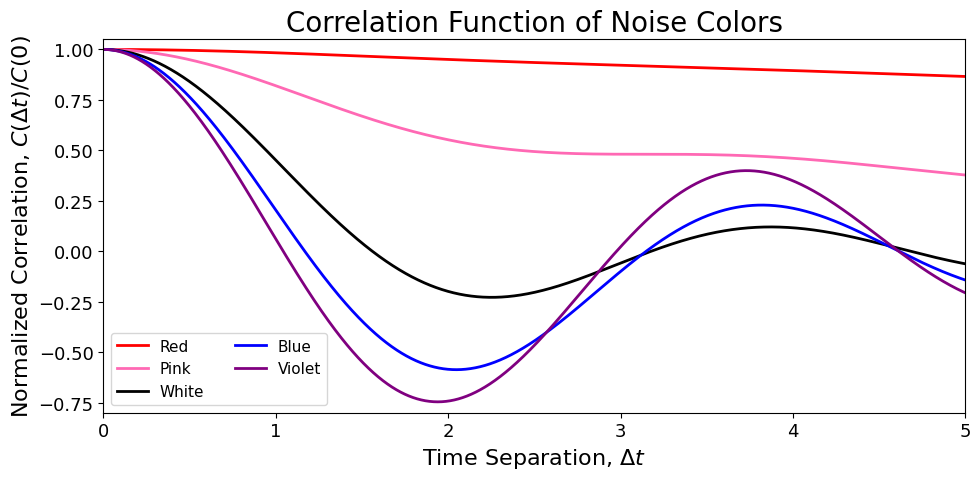

In [242]:
#Defines the time range and frequency range used to calculate the correlation function directly from the power spectral density.
maxCorrelationTime = 5.0
omegaMin = 0.01/tau
omegaMax = 1.0/tau

#Chooses a long enough fast fourier transform grid to resolve lowest frequency and desired correlation times.
minimumLength = max(8.0*maxCorrelationTime, 2.0*np.pi/omegaMin)
fftLength = 2**int(np.ceil(np.log2(minimumLength/deltat)))
frequencyList = np.fft.rfftfreq(fftLength, d=deltat)
omegaList = 2.0*np.pi*frequencyList
correlationTimeList = np.arange(fftLength)*deltat
numCorrelationPoints = int(round(maxCorrelationTime/deltat))+1

correlationFromPSD = {}
psdFromFrequency = {}

#Builds each power spectral density from the power law using the same frequency range.
for noiseType in noiseTypes:
    exponent = noiseExponents[noiseType]
    psdList = np.zeros_like(omegaList)
    frequencyMask = (omegaList>=omegaMin)&(omegaList<=omegaMax)
    psdList[frequencyMask] = omegaList[frequencyMask]**exponent

    #Uses the inverse Fourier transform of the power spectral density to get the correlation function.
    correlation = np.fft.irfft(psdList, n=fftLength)

    #Scales the correlation so its value with no time separation is equal to the noise variance.
    correlation *= sigma**2/correlation[0]
    psdFromFrequency[noiseType] = psdList

    #Normalizes each correlation so every curve starts at one.
    correlationFromPSD[noiseType] = correlation[:numCorrelationPoints]/correlation[0]

#Plots the correlation functions for each noise color.
plt.figure(figsize=(10, 5))

for noiseType in noiseTypes:
    plt.plot(correlationTimeList[:numCorrelationPoints], correlationFromPSD[noiseType], color=noiseColors[noiseType], label=noiseLabels[noiseType], linewidth=2)

plt.xlim(0.0, maxCorrelationTime)
plt.ylim(-0.8, 1.05)
plt.title("Correlation Function of Noise Colors")
plt.xlabel(r"Time Separation, $\Delta t$")
plt.ylabel(r"Normalized Correlation, $C(\Delta t)/C(0)$")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()